# Generalization and Error Analysis

This notebook investigates why the AI-text detection models performed near-perfectly on the original test set but substantially worse on the external HC3 dataset.

The analysis focuses on:
- error patterns
- prediction bias
- text-length effects
- confidence behavior
- representative misclassified examples

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
model_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Original F1": 0.993275,
        "HC3 F1": 0.538655,
        "HC3 Accuracy": 0.469753,
        "HC3 Precision": 0.378184,
        "HC3 Recall": 0.935683,
        "HC3 ROC-AUC": 0.758304
    },
    {
        "Model": "SVM",
        "Original F1": 0.999155,
        "HC3 F1": 0.570157,
        "HC3 Accuracy": 0.561785,
        "HC3 Precision": 0.422031,
        "HC3 Recall": 0.878491,
        "HC3 ROC-AUC": 0.764126
    },
    {
        "Model": "RoBERTa",
        "Original F1": 0.998642,
        "HC3 F1": 0.564608,
        "HC3 Accuracy": 0.490098,
        "HC3 Precision": 0.393448,
        "HC3 Recall": 0.999352,
        "HC3 ROC-AUC": 0.845700
    },
    {
        "Model": "DeBERTa",
        "Original F1": 0.994764,
        "HC3 F1": 0.568831,
        "HC3 Accuracy": 0.498594,
        "HC3 Precision": 0.397516,
        "HC3 Recall": 0.999996,
        "HC3 ROC-AUC": 0.804842
    }
])

model_summary

,Model,Original F1,HC3 F1,HC3 Accuracy,HC3 Precision,HC3 Recall,HC3 ROC-AUC
0,Logistic Regression,0.993275,0.538655,0.469753,0.378184,0.935683,0.758304
1,SVM,0.999155,0.570157,0.561785,0.422031,0.878491,0.764126
2,RoBERTa,0.998642,0.564608,0.490098,0.393448,0.999352,0.845700
3,DeBERTa,0.994764,0.568831,0.498594,0.397516,0.999996,0.804842


In [3]:
model_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Original F1": 0.993275,
        "HC3 F1": 0.538655,
        "HC3 Accuracy": 0.469753,
        "HC3 Precision": 0.378184,
        "HC3 Recall": 0.935683,
        "HC3 ROC-AUC": 0.758304
    },
    {
        "Model": "SVM",
        "Original F1": 0.999155,
        "HC3 F1": 0.570157,
        "HC3 Accuracy": 0.561785,
        "HC3 Precision": 0.422031,
        "HC3 Recall": 0.878491,
        "HC3 ROC-AUC": 0.764126
    },
    {
        "Model": "RoBERTa",
        "Original F1": 0.998642,
        "HC3 F1": 0.564608,
        "HC3 Accuracy": 0.490098,
        "HC3 Precision": 0.393448,
        "HC3 Recall": 0.999352,
        "HC3 ROC-AUC": 0.845700
    },
    {
        "Model": "DeBERTa",
        "Original F1": 0.994764,
        "HC3 F1": 0.568831,
        "HC3 Accuracy": 0.498594,
        "HC3 Precision": 0.397516,
        "HC3 Recall": 0.999996,
        "HC3 ROC-AUC": 0.804842
    }
])

model_summary

,Model,Original F1,HC3 F1,HC3 Accuracy,HC3 Precision,HC3 Recall,HC3 ROC-AUC
0,Logistic Regression,0.993275,0.538655,0.469753,0.378184,0.935683,0.758304
1,SVM,0.999155,0.570157,0.561785,0.422031,0.878491,0.764126
2,RoBERTa,0.998642,0.564608,0.490098,0.393448,0.999352,0.845700
3,DeBERTa,0.994764,0.568831,0.498594,0.397516,0.999996,0.804842


In [4]:
model_summary["Absolute F1 Drop"] = (
    model_summary["Original F1"] -
    model_summary["HC3 F1"]
)

model_summary["Relative F1 Drop (%)"] = (
    model_summary["Absolute F1 Drop"] /
    model_summary["Original F1"]
) * 100

model_summary[
    [
        "Model",
        "Original F1",
        "HC3 F1",
        "Absolute F1 Drop",
        "Relative F1 Drop (%)"
    ]
]

,Model,Original F1,HC3 F1,Absolute F1 Drop,Relative F1 Drop (%)
0,Logistic Regression,0.993275,0.538655,0.454620,45.769802
1,SVM,0.999155,0.570157,0.428998,42.936081
2,RoBERTa,0.998642,0.564608,0.434034,43.462422
3,DeBERTa,0.994764,0.568831,0.425933,42.817492


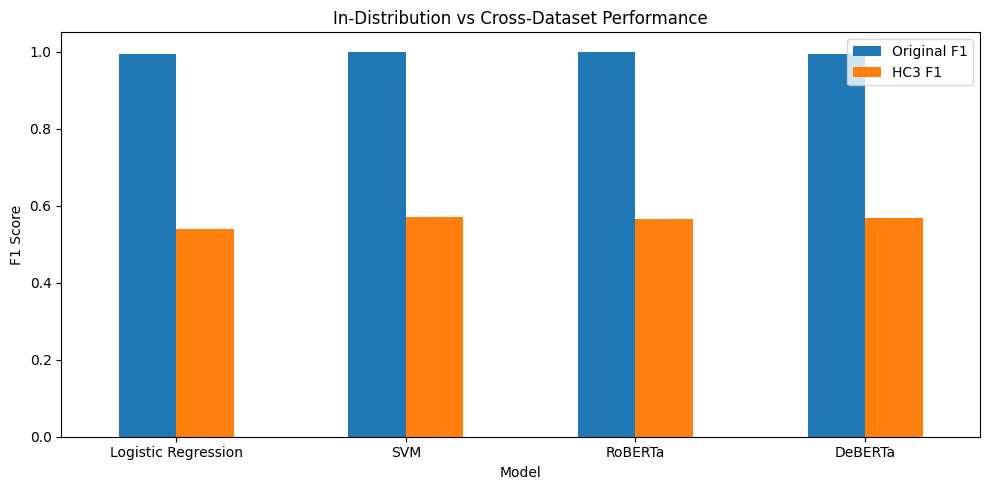

In [5]:
plot_df = model_summary.set_index("Model")[
    ["Original F1", "HC3 F1"]
]

plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("In-Distribution vs Cross-Dataset Performance")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

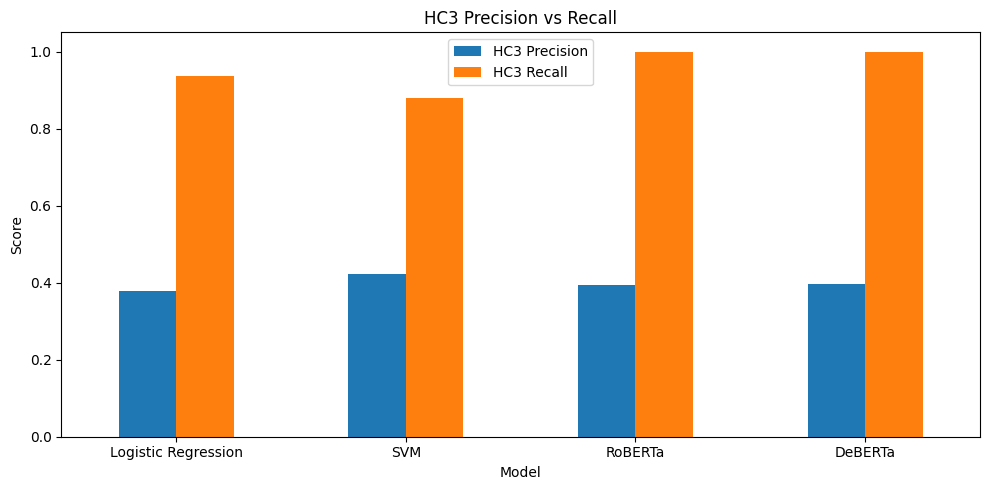

In [6]:
precision_recall_df = model_summary.set_index("Model")[
    ["HC3 Precision", "HC3 Recall"]
]

precision_recall_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("HC3 Precision vs Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
def prediction_rate(predictions):
    return (predictions == 1).mean()

In [8]:
print("Logistic AI prediction rate:", prediction_rate(logistic_external_preds))
print("SVM AI prediction rate:", prediction_rate(svm_external_preds))

NameError: name 'logistic_external_preds' is not defined

In [9]:
actual_ai_rate = (hc3_df["generated"] == 1).mean()

print("Actual HC3 AI rate:", actual_ai_rate)

NameError: name 'hc3_df' is not defined